In [ ]:
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np


# --- INPUT CONFIG (aligned with noise_ceiling_analysis) ---
PROJECT_ROOT = Path("../../../../Image_Authenticity_prediction/").resolve()
NUMBER_EXPECTED_FILES = 25
REMOVED_IMAGES_FILE = PROJECT_ROOT / "Dataset" / "AIGCIQA2023" / "removed_images.txt"
SINGLE_SCORES_FILES = PROJECT_ROOT / "Dataset" / "Single_scores" 

# --- OUTPUT CONFIG ---
BASE_DIR = PROJECT_ROOT / "main" / "Experiments" / "Outputs" / "URI_Paper_Plots"
PLOT_DIR = BASE_DIR / "Plots"
SAVE_PER_IMAGE_CSV = BASE_DIR / "per_image_means_QAM.csv"

# Create output directories
BASE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print("✓ Output directories created/verified:")
print(f"  - BASE_DIR: {BASE_DIR}")
print(f"  - PLOT_DIR: {PLOT_DIR}")

# --- REMOVED IDS ---
removed_ids = set()

if REMOVED_IMAGES_FILE.exists():
    print(f"Loading removed IDs from: {REMOVED_IMAGES_FILE}\n")
    with open(REMOVED_IMAGES_FILE, "r", encoding="utf-8") as f:
        for line in f:
            orig = line.rstrip("\n")
            line = orig.strip()
            if not line:
                continue
            try:
                removed_ids.add(int(Path(line).stem))
            except ValueError:
                print(f"[WARN] Could not parse ID from {orig}")
else:
    print(f"[WARN] removed_images file not found at {REMOVED_IMAGES_FILE}, no IDs excluded.")


# --- CONTAINERS ---
quality = defaultdict(list)          # raw Q
authenticity = defaultdict(list)     # raw A
authenticity_z = defaultdict(list)   # z-scored A
match = defaultdict(list)

loaded_files = []
total_rows = 0


def _coerce_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def load_file(fp: Path) -> pd.DataFrame:
    """
    Standardize to columns:
    ['uniqueID','Quality','Authenticity','Match']
    """
    suffix = fp.suffix.lower()

    if suffix in {".xlsx", ".xls"}:
        df = pd.read_excel(fp, usecols="B:G", header=0)
        if df.shape[1] < 6:
            df = pd.read_excel(fp, usecols="B:G", header=None)

        B = _coerce_numeric(df.iloc[:, 0])
        E = _coerce_numeric(df.iloc[:, 3])
        F = _coerce_numeric(df.iloc[:, 4])
        G = _coerce_numeric(df.iloc[:, 5])

    elif suffix == ".csv":
        try:
            tmp = pd.read_csv(fp, header=0)
        except Exception:
            tmp = pd.read_csv(fp, header=None)

        B = _coerce_numeric(tmp.iloc[:, 1])
        E = _coerce_numeric(tmp.iloc[:, 4])
        F = _coerce_numeric(tmp.iloc[:, 5])
        G = _coerce_numeric(tmp.iloc[:, 6])

    else:
        raise ValueError(f"Unsupported file type: {fp.name}")

    out = pd.DataFrame({
        "uniqueID": B.astype("Int64"),
        "Quality": E,
        "Authenticity": F,
        "Match": G
    })

    out = out.dropna(subset=["uniqueID"])
    out = out.dropna(subset=["Quality", "Authenticity", "Match"], how="all")

    return out


# --- SELECT SOURCE FILES (aligned with noise_ceiling_analysis) ---
SOURCE_CSVS = sorted(SINGLE_SCORES_FILES.glob("*_scores.csv"))
source_excels = sorted(p for p in SINGLE_SCORES_FILES.iterdir() if p.suffix.lower() in {".xlsx", ".xls"})
files = SOURCE_CSVS if SOURCE_CSVS else source_excels

if not files:
    raise FileNotFoundError(
        f"No source files found. Looked for '*_scores.csv' or Excel files in {SINGLE_SCORES_FILES}"
)

print(f"\n=== Loading {NUMBER_EXPECTED_FILES} Single Scores Files ===")
print(f"Source directory: {SINGLE_SCORES_FILES}")
print(f"Found {len(files)} files matching pattern")


# --- LOAD FILES ---
for fp in files:
    try:
        df = load_file(fp)

        # --- Z-NORMALIZE AUTHENTICITY WITHIN RATER ---
        a_vals = df["Authenticity"].astype(float)
        a_mean = a_vals.mean()
        a_std = a_vals.std(ddof=0)

        if a_std == 0 or np.isnan(a_std):
            df["A_z"] = np.nan
        else:
            df["A_z"] = (a_vals - a_mean) / a_std

        for _, row in df.iterrows():
            uid = row["uniqueID"]
            if pd.isna(uid):
                continue
            uid = int(uid)

            if uid in removed_ids:
                continue

            if pd.notna(row["Quality"]):
                quality[uid].append(float(row["Quality"]))

            if pd.notna(row["Authenticity"]):
                authenticity[uid].append(float(row["Authenticity"]))

            if pd.notna(row["A_z"]):
                authenticity_z[uid].append(float(row["A_z"]))

            if pd.notna(row["Match"]):
                match[uid].append(float(row["Match"]))

        loaded_files.append(fp.name)
        total_rows += len(df)

    except Exception as e:
        print(f"[WARN] Skipping {fp.name}: {e}")


# --- HELPERS ---
def safe_mean(arr):
    return float(np.nanmean(arr)) if len(arr) else float("nan")

def safe_sd(arr):
    return float(np.nanstd(arr, ddof=1)) if len(arr) > 1 else float("nan")


# --- PER-IMAGE SUMMARY ---
all_ids = sorted(set(quality) | set(authenticity) | set(match))

rows = []
for uid in all_ids:
    q = np.array(quality.get(uid, []))
    a = np.array(authenticity.get(uid, []))
    az = np.array(authenticity_z.get(uid, []))
    m = np.array(match.get(uid, []))

    rows.append({
        "uniqueID": uid,

        "Q_mean": safe_mean(q),
        "Q_n": len(q),

        "A_mean": safe_mean(a),
        "A_n": len(a),

        "A_sd_z": safe_sd(az),   # z-scored across raters

        "M_mean": safe_mean(m),
        "M_n": len(m),
    })

per_image_df = pd.DataFrame(rows).sort_values("uniqueID").reset_index(drop=True)

# --- SAVE ---
per_image_df.to_csv(SAVE_PER_IMAGE_CSV, index=False)

print(f"\nSaved per-image summary to: {SAVE_PER_IMAGE_CSV}")
print(f"Loaded {len(loaded_files)} files (expected ~{NUMBER_EXPECTED_FILES}).")
print(f"Total usable rows: {total_rows}")
print(f"Unique images: {len(all_ids)}")

✓ Output directories created/verified:
  - BASE_DIR: /home/icaro.redepaolini@unitn.it/icaro_rdp_projects/Image_Authenticity_prediction/Image_Authenticity_prediction/main/Experiments/Outputs/URI_Paper_Plots
  - PLOT_DIR: /home/icaro.redepaolini@unitn.it/icaro_rdp_projects/Image_Authenticity_prediction/Image_Authenticity_prediction/main/Experiments/Outputs/URI_Paper_Plots/Plots
[WARN] removed_images file not found at /home/icaro.redepaolini@unitn.it/icaro_rdp_projects/Image_Authenticity_prediction/Image_Authenticity_prediction/Dataset/AIGCIQA2023/removed_images.txt, no IDs excluded.


FileNotFoundError: [Errno 2] No such file or directory: '/home/icaro.redepaolini@unitn.it/icaro_rdp_projects/Image_Authenticity_prediction/Image_Authenticity_prediction/Dataset/Single_scores'

# sanity check for data

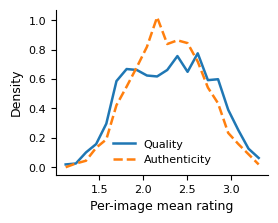

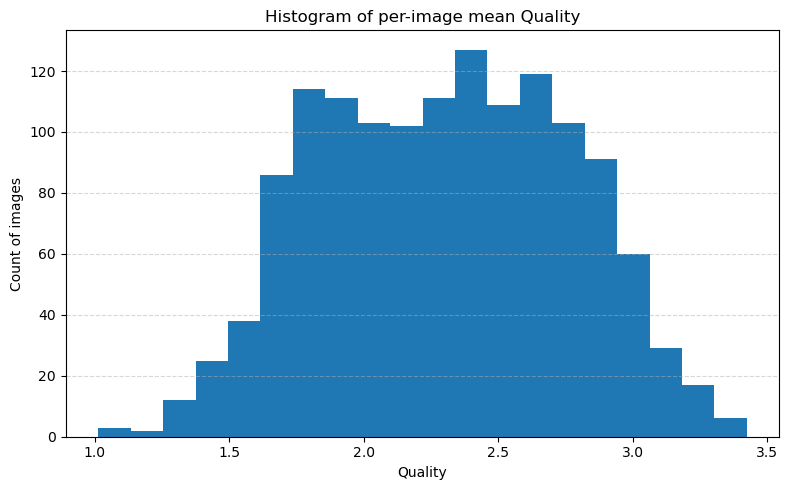

Saved: C:\Users\uri.hasson\Documents\prog\icaro\signaltonoise\AIGI2023_results\AIGI2023_results\hist_per_image_mean_Quality.png


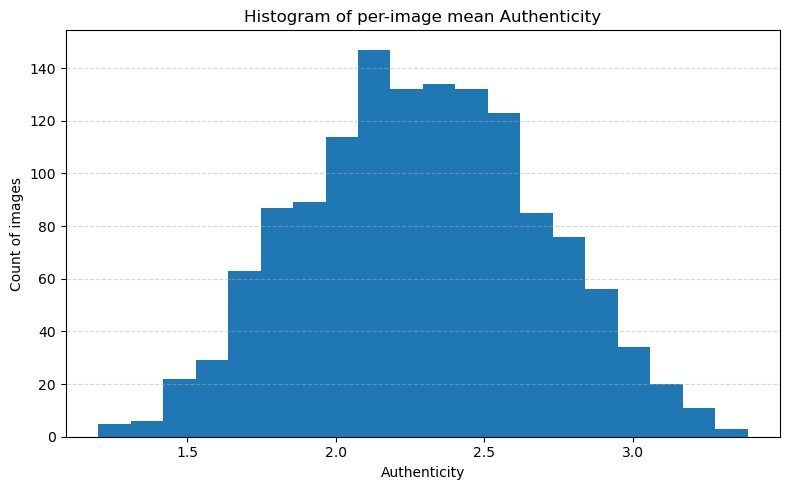

Saved: C:\Users\uri.hasson\Documents\prog\icaro\signaltonoise\AIGI2023_results\AIGI2023_results\hist_per_image_mean_Authenticity.png


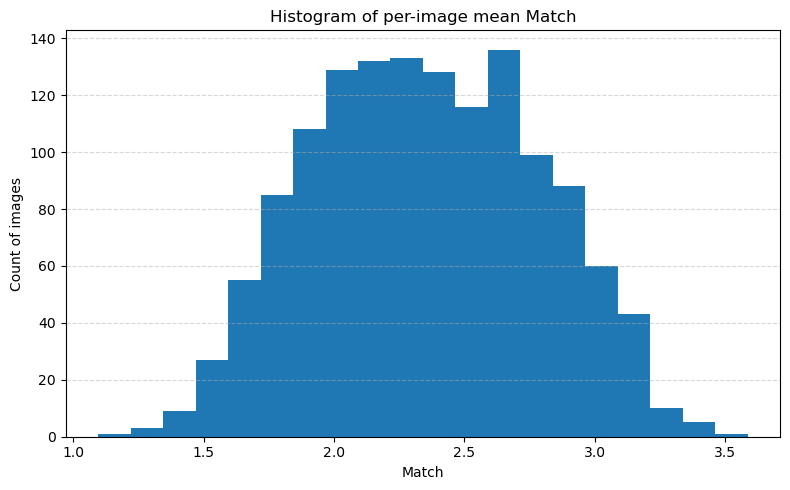

Saved: C:\Users\uri.hasson\Documents\prog\icaro\signaltonoise\AIGI2023_results\AIGI2023_results\hist_per_image_mean_Match.png


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATA TO PLOT (per-image means)
# =========================
Q = per_image_df["Q_mean"].dropna().values
A = per_image_df["A_mean"].dropna().values

# =========================
# FIGURE CONFIG (1/3 A4)
# =========================
fig_width = 2.75   # inches (~1/3 A4 width)
fig_height = 2.2
bins = 20

# Shared bins (VERY IMPORTANT)
xmin = min(Q.min(), A.min())
xmax = max(Q.max(), A.max())
bin_edges = np.linspace(xmin, xmax, bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Density histograms
q_hist, _ = np.histogram(Q, bins=bin_edges, density=True)
a_hist, _ = np.histogram(A, bins=bin_edges, density=True)

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

ax.plot(bin_centers, q_hist, linewidth=1.8, label="Quality")
ax.plot(bin_centers, a_hist, linewidth=1.8, linestyle="--", label="Authenticity")

# Labels
ax.set_xlabel("Per-image mean rating", fontsize=9)
ax.set_ylabel("Density", fontsize=9)

# Styling (publication)
ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=8, handlelength=2)

plt.tight_layout(pad=0.6)
plt.show()
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIG ---
out_dir = base_dir  # or Path(".")
bins = 20          

def plot_hist(series, metric_name, out_dir, bins=20):
    s = series.dropna().astype(float)
    if s.empty:
        print(f"[WARN] No data for {metric_name}; skipping histogram.")
        return
    # If values look like proportions (<=1), plot as percentages
    as_percent = np.nanmax(s.values) <= 1.05
    if as_percent:
        x = s.values * 100.0
        x_label = f"{metric_name} (%)"
        hist_range = (0, 100)
    else:
        x = s.values
        x_label = f"{metric_name}"
        # auto-range with a small margin
        xmin, xmax = np.nanmin(x), np.nanmax(x)
        span = xmax - xmin
        hist_range = (xmin - 0.02*span, xmax + 0.02*span) if span > 0 else (xmin - 1, xmax + 1)

    plt.figure(figsize=(8, 5))
    plt.hist(x, bins=bins, range=hist_range)
    plt.title(f"Histogram of per-image mean {metric_name}")
    plt.xlabel(x_label)
    plt.ylabel("Count of images")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    fname = out_dir / f"hist_per_image_mean_{metric_name.replace(' ', '')}.png"
    plt.savefig(fname, dpi=200)
    plt.show()
    print(f"Saved: {fname}")

# --- PLOT ---
plot_hist(per_image_df["Q_mean"], "Quality", out_dir, bins=bins)
plot_hist(per_image_df["A_mean"], "Authenticity", out_dir, bins=bins)
plot_hist(per_image_df["M_mean"], "Match", out_dir, bins=bins)


# draft1 psychometric properties

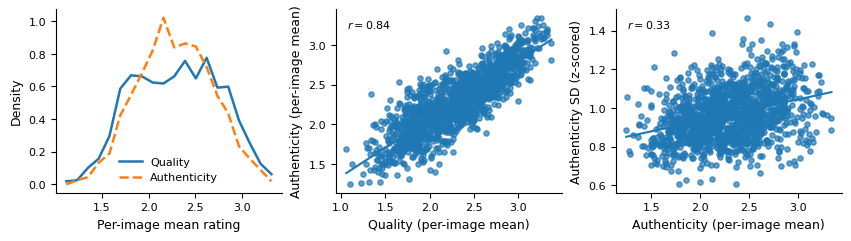

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# ==============================
# PUBLICATION-QUALITY PLOTS
# ==============================

# --- DATA ---
Qm = per_image_df["Q_mean"].values
Am = per_image_df["A_mean"].values
Asd = per_image_df["A_sd_z"].values   # SD of z-scored authenticity ratings

# Masks for valid values
mask_QA = np.isfinite(Qm) & np.isfinite(Am)
mask_ASD = np.isfinite(Am) & np.isfinite(Asd)

Qm_QA = Qm[mask_QA]
Am_QA = Am[mask_QA]

Am_ASD = Am[mask_ASD]
Asd_ASD = Asd[mask_ASD]

# --- FIGURE SETUP ---
fig, axes = plt.subplots(
    1, 3,
    figsize=(8.4, 2.3),   # ~full A4 width (3 × 1/3 A4)
    constrained_layout=True
)

# =====================================================
# PANEL 1: Density histograms of per-image means
# =====================================================
ax = axes[0]

bins = np.linspace(
    min(Qm_QA.min(), Am_QA.min()),
    max(Qm_QA.max(), Am_QA.max()),
    21
)

q_hist, _ = np.histogram(Qm_QA, bins=bins, density=True)
a_hist, _ = np.histogram(Am_QA, bins=bins, density=True)
centers = 0.5 * (bins[:-1] + bins[1:])

ax.plot(centers, q_hist, linewidth=1.8, label="Quality")
ax.plot(centers, a_hist, linewidth=1.8, linestyle="--", label="Authenticity")

ax.set_xlabel("Per-image mean rating", fontsize=9)
ax.set_ylabel("Density", fontsize=9)

ax.legend(frameon=False, fontsize=8, handlelength=2)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =====================================================
# PANEL 2: Correlation Q_mean vs A_mean
# =====================================================
ax = axes[1]

r, _ = pearsonr(Qm_QA, Am_QA)

ax.scatter(Qm_QA, Am_QA, s=14, alpha=0.7)

coef = np.polyfit(Qm_QA, Am_QA, 1)
xline = np.linspace(Qm_QA.min(), Qm_QA.max(), 100)
ax.plot(xline, coef[0] * xline + coef[1], linewidth=1.5)

ax.set_xlabel("Quality (per-image mean)", fontsize=9)
ax.set_ylabel("Authenticity (per-image mean)", fontsize=9)

ax.text(
    0.05, 0.95,
    f"$r = {r:.2f}$",
    transform=ax.transAxes,
    fontsize=8,
    va="top"
)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =====================================================
# PANEL 3: Correlation A_mean vs A_SD (z-scored)
# =====================================================
ax = axes[2]

r_sd, _ = pearsonr(Am_ASD, Asd_ASD)

ax.scatter(Am_ASD, Asd_ASD, s=14, alpha=0.7)

coef = np.polyfit(Am_ASD, Asd_ASD, 1)
xline = np.linspace(Am_ASD.min(), Am_ASD.max(), 100)
ax.plot(xline, coef[0] * xline + coef[1], linewidth=1.5)

ax.set_xlabel("Authenticity (per-image mean)", fontsize=9)
ax.set_ylabel("Authenticity SD (z-scored)", fontsize=9)

ax.text(
    0.05, 0.95,
    f"$r = {r_sd:.2f}$",
    transform=ax.transAxes,
    fontsize=8,
    va="top"
)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


# draft2 psychometric properties

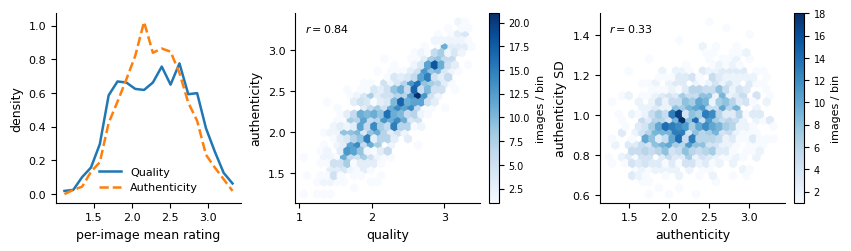

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# ==============================
# DATA
# ==============================
Qm = per_image_df["Q_mean"].values
Am = per_image_df["A_mean"].values
Asd = per_image_df["A_sd_z"].values   # SD of z-normalized authenticity

# Masks for valid data
m12 = np.isfinite(Qm) & np.isfinite(Am)
m23 = np.isfinite(Am) & np.isfinite(Asd)

Qm12, Am12 = Qm[m12], Am[m12]
Am23, Asd23 = Am[m23], Asd[m23]

# ==============================
# FIGURE SETUP
# ==============================
fig, axes = plt.subplots(
    1, 3,
    figsize=(8.4, 2.4),   # ~full A4 width
    constrained_layout=True
)

# =====================================================
# PANEL 1: Density histograms (per-image means)
# =====================================================
ax = axes[0]

bins = np.linspace(
    min(Qm12.min(), Am12.min()),
    max(Qm12.max(), Am12.max()),
    21
)

q_hist, _ = np.histogram(Qm12, bins=bins, density=True)
a_hist, _ = np.histogram(Am12, bins=bins, density=True)
centers = 0.5 * (bins[:-1] + bins[1:])

ax.plot(centers, q_hist, linewidth=1.8, label="Quality")
ax.plot(centers, a_hist, linewidth=1.8, linestyle="--", label="Authenticity")

ax.set_xlabel("per-image mean rating", fontsize=9)
ax.set_ylabel("density", fontsize=9)

ax.legend(frameon=False, fontsize=8, handlelength=2)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# =====================================================
# PANEL 2: Hexbin — quality vs authenticity
# =====================================================
ax = axes[1]

hb = ax.hexbin(
    Qm12, Am12,
    gridsize=25,
    cmap="Blues",
    mincnt=1
)

r, _ = pearsonr(Qm12, Am12)

ax.set_xlabel("quality", fontsize=9)
ax.set_ylabel("authenticity", fontsize=9)

ax.text(
    0.05, 0.95,
    f"$r = {r:.2f}$",
    transform=ax.transAxes,
    fontsize=8,
    va="top"
)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("images / bin", fontsize=8)
cb.ax.tick_params(labelsize=7)

# =====================================================
# PANEL 3: Hexbin — authenticity mean vs SD
# =====================================================
ax = axes[2]

hb = ax.hexbin(
    Am23, Asd23,
    gridsize=25,
    cmap="Blues",
    mincnt=1
)

r, _ = pearsonr(Am23, Asd23)

ax.set_xlabel("authenticity", fontsize=9)
ax.set_ylabel("authenticity SD", fontsize=9)

ax.text(
    0.05, 0.95,
    f"$r = {r:.2f}$",
    transform=ax.transAxes,
    fontsize=8,
    va="top"
)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("images / bin", fontsize=8)
cb.ax.tick_params(labelsize=7)

plt.show()


# final psychometric figure

Saved figure to: C:\Users\uri.hasson\Documents\prog\icaro\signaltonoise\AIGI2023_results\AIGI2023_results\figure_auth_quality.pdf


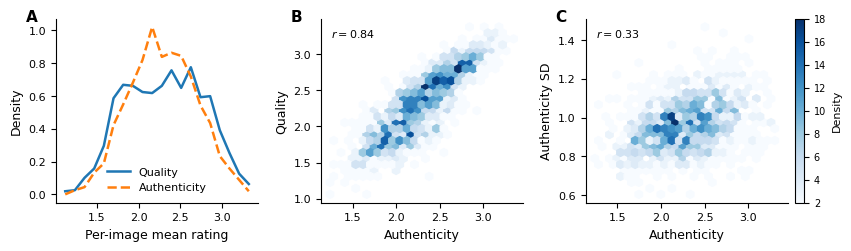

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# ==============================
# DATA
# ==============================
Qm = per_image_df["Q_mean"].values
Am = per_image_df["A_mean"].values
Asd = per_image_df["A_sd_z"].values   # SD of z-normalized authenticity

# Masks
m12 = np.isfinite(Qm) & np.isfinite(Am)
m23 = np.isfinite(Am) & np.isfinite(Asd)

Qm12, Am12 = Qm[m12], Am[m12]
Am23, Asd23 = Am[m23], Asd[m23]

# ==============================
# FIGURE SETUP
# ==============================
fig, axes = plt.subplots(
    1, 3,
    figsize=(8.4, 2.4),   # ~full A4 width
    constrained_layout=True
)
fig.set_constrained_layout_pads(wspace=0.06, hspace=0.02)

# =====================================================
# PANEL A: Density histograms (per-image means)
# =====================================================
ax = axes[0]

bins = np.linspace(
    min(Qm12.min(), Am12.min()),
    max(Qm12.max(), Am12.max()),
    21
)

q_hist, _ = np.histogram(Qm12, bins=bins, density=True)
a_hist, _ = np.histogram(Am12, bins=bins, density=True)
centers = 0.5 * (bins[:-1] + bins[1:])

# Line-style distinction instead of alpha
ax.plot(centers, q_hist, linewidth=1.8, linestyle="-", label="Quality")
ax.plot(centers, a_hist, linewidth=1.8, linestyle="--", label="Authenticity")

ax.set_xlabel("Per-image mean rating", fontsize=9)
ax.set_ylabel("Density", fontsize=9)

ax.legend(frameon=False, fontsize=8, handlelength=2)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.text(
    -0.15, 1.05, "A",
    transform=ax.transAxes,
    fontsize=11, fontweight="bold", va="top"
)

# =====================================================
# SHARED COLOR SCALE FOR HEXBINS
# =====================================================
vmin, vmax = 2, 18

# =====================================================
# PANEL B: Hexbin — Authenticity vs Quality
# =====================================================
ax = axes[1]

hb1 = ax.hexbin(
    Am12, Qm12,
    gridsize=25,
    cmap="Blues",
    mincnt=1,
    vmin=vmin,
    vmax=vmax
)

r, _ = pearsonr(Am12, Qm12)

ax.set_xlabel("Authenticity", fontsize=9)
ax.set_ylabel("Quality", fontsize=9)

ax.text(
    0.05, 0.95, f"$r = {r:.2f}$",
    transform=ax.transAxes, fontsize=8, va="top"
)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.text(
    -0.15, 1.05, "B",
    transform=ax.transAxes,
    fontsize=11, fontweight="bold", va="top"
)

# =====================================================
# PANEL C: Hexbin — Authenticity mean vs SD
# =====================================================
ax = axes[2]

hb2 = ax.hexbin(
    Am23, Asd23,
    gridsize=25,
    cmap="Blues",
    mincnt=1,
    vmin=vmin,
    vmax=vmax
)

r, _ = pearsonr(Am23, Asd23)

ax.set_xlabel("Authenticity", fontsize=9)
ax.set_ylabel("Authenticity SD", fontsize=9)

ax.text(
    0.05, 0.95, f"$r = {r:.2f}$",
    transform=ax.transAxes, fontsize=8, va="top"
)

ax.tick_params(axis="both", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

ax.text(
    -0.15, 1.05, "C",
    transform=ax.transAxes,
    fontsize=11, fontweight="bold", va="top"
)

# =====================================================
# SINGLE SHARED COLORBAR
# =====================================================
cbar = fig.colorbar(hb1, ax=axes, location="right", pad=0.01)
cbar.set_label("Density", fontsize=8)
cbar.ax.tick_params(labelsize=7)

# =====================================================
# SAVE (Overleaf-ready)
# =====================================================
outpath = base_dir / "figure_auth_quality.pdf"

fig.savefig(
    outpath,
    format="pdf",
    bbox_inches="tight",
    dpi=300
)

print(f"Saved figure to: {outpath}")

plt.savefig(
    outpath,
    format="pdf",
    bbox_inches="tight"
)



plt.show()


In [6]:
plt.savefig(
    "figure_auth_quality.pdf",
    format="pdf",
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

# final cross architechture similarity

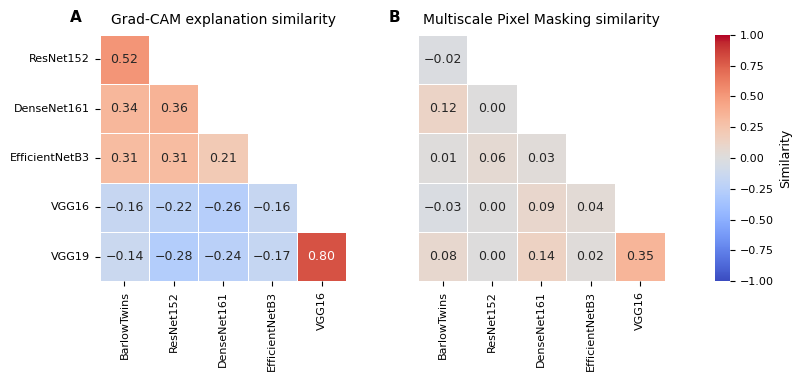

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

architectures = [
    "BarlowTwins",
    "ResNet152",
    "DenseNet161",
    "EfficientNetB3",
    "VGG16",
    "VGG19"
]

# Original data (6x5)
gradcam_means = np.array([
    [np.nan, np.nan, np.nan, np.nan, np.nan],
    [0.52,   np.nan, np.nan, np.nan, np.nan],
    [0.34,   0.36,   np.nan, np.nan, np.nan],
    [0.31,   0.31,   0.21,   np.nan, np.nan],
    [-0.16, -0.22,  -0.26,  -0.16,   np.nan],
    [-0.14, -0.28,  -0.24,  -0.17,    0.80]
])

mpm_means = np.array([
    [np.nan, np.nan, np.nan, np.nan, np.nan],
    [-0.02,  np.nan, np.nan, np.nan, np.nan],
    [0.12,   0.00,   np.nan, np.nan, np.nan],
    [0.01,   0.06,   0.03,   np.nan, np.nan],
    [-0.03,  0.00,   0.09,   0.04,    np.nan],
    [0.08,   0.00,   0.14,   0.02,    0.35]
])

# -------------------------------------------------
# REMOVE the first (all-NaN) row → get 5×5 matrices
# -------------------------------------------------
gradcam_plot = gradcam_means[1:, :]
mpm_plot     = mpm_means[1:, :]

row_labels = architectures[1:]   # ResNet152 … VGG19
col_labels = architectures[:-1]  # BarlowTwins … VGG16

mask_gc  = np.isnan(gradcam_plot)
mask_mpm = np.isnan(mpm_plot)

def format_annot(x):
    if np.isnan(x):
        return ""
    return f"{x:.2f}".replace("-", "−")  # typographic minus

# ----------------
# Figure layout
# ----------------
fig = plt.figure(figsize=(8.4, 3.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.15)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

vmin, vmax = -1, 1
cmap = "coolwarm"

# Panel A
sns.heatmap(
    gradcam_plot,
    mask=mask_gc,
    ax=ax1,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    linewidths=0.4,
    linecolor="white",
    annot=np.vectorize(format_annot)(gradcam_plot),
    fmt="",
    annot_kws=dict(size=9),
    cbar=False,
    xticklabels=col_labels,
    yticklabels=row_labels
)

ax1.set_title("Grad-CAM explanation similarity", fontsize=10, pad=8)
ax1.tick_params(axis="both", labelsize=8)
ax1.text(-0.12, 1.04, "A", transform=ax1.transAxes,
         fontsize=11, fontweight="bold", va="bottom")

# Panel B
sns.heatmap(
    mpm_plot,
    mask=mask_mpm,
    ax=ax2,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    square=True,
    linewidths=0.4,
    linecolor="white",
    annot=np.vectorize(format_annot)(mpm_plot),
    fmt="",
    annot_kws=dict(size=9),
    cbar=True,
    cbar_ax=cax,
    xticklabels=col_labels,
    yticklabels=False
)

ax2.set_title("Multiscale Pixel Masking similarity", fontsize=10, pad=8)
ax2.tick_params(axis="both", labelsize=8)
ax2.text(-0.12, 1.04, "B", transform=ax2.transAxes,
         fontsize=11, fontweight="bold", va="bottom")

# Colorbar
cax.set_ylabel("Similarity", fontsize=9)
cax.tick_params(labelsize=8)

# Save for Overleaf (vector, publication quality)
plt.savefig(
    "explanation_similarity_matrices.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()



# draft high-low agreement figure for gradcam

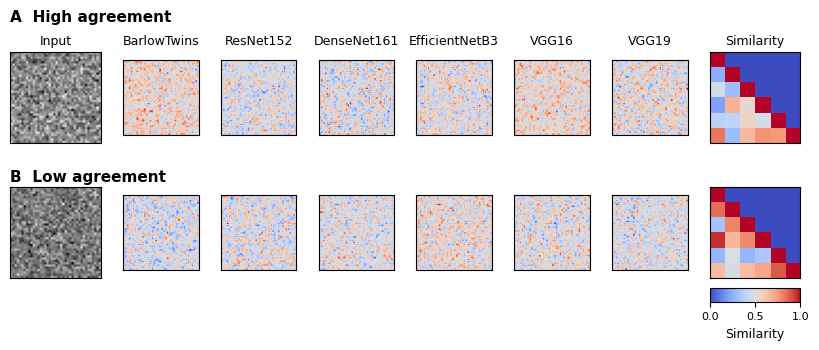

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ------------------------------
# Configuration
# ------------------------------
models = ["BarlowTwins", "ResNet152", "DenseNet161",
          "EfficientNetB3", "VGG16", "VGG19"]

n_models = len(models)
np.random.seed(0)

def fake_image(seed):
    rng = np.random.default_rng(seed)
    return rng.normal(0, 1, (40, 40))

def fake_similarity(seed):
    rng = np.random.default_rng(seed)
    M = rng.uniform(0.2, 1.0, (n_models, n_models))
    M = np.tril(M)
    np.fill_diagonal(M, 1.0)
    return M

# ------------------------------
# Figure layout (A4-ready)
# ------------------------------
fig = plt.figure(figsize=(8.5, 3.8))

# Columns: Input | 6 models | Similarity
widths = [1.2] + [1]*6 + [1.2]

gs = GridSpec(
    2, len(widths),
    width_ratios=widths,
    height_ratios=[1, 1],
    left=0.05, right=0.98,
    top=0.82, bottom=0.22,   # room for headers + colorbar
    wspace=0.28, hspace=0.45
)

# ------------------------------
# Panel labels (above rows)
# ------------------------------
fig.text(0.05, 0.91, "A  High agreement",
         fontsize=11, fontweight="bold", ha="left", va="center")

fig.text(0.05, 0.49, "B  Low agreement",
         fontsize=11, fontweight="bold", ha="left", va="center")

# ------------------------------
# Column headers (top row only)
# ------------------------------
x_positions = []
for c in range(len(widths)):
    bbox = gs[0, c].get_position(fig)
    x_positions.append((bbox.x0 + bbox.x1) / 2)

headers = ["Input"] + models + ["Similarity"]

for x, label in zip(x_positions, headers):
    fig.text(x, 0.83, label, fontsize=9, ha="center", va="bottom")

# ------------------------------
# Input images
# ------------------------------
for r in range(2):
    ax = fig.add_subplot(gs[r, 0])
    ax.imshow(fake_image(10 + r), cmap="gray")
    ax.set_xticks([]); ax.set_yticks([])

# ------------------------------
# Grad-CAM explanation placeholders
# ------------------------------
for r in range(2):
    for c in range(n_models):
        ax = fig.add_subplot(gs[r, 1 + c])
        ax.imshow(fake_image(100*r + c), cmap="coolwarm")
        ax.set_xticks([]); ax.set_yticks([])

# ------------------------------
# Similarity matrices (lower triangle)
# ------------------------------
for r in range(2):
    ax = fig.add_subplot(gs[r, -1])
    sim = fake_similarity(50 + r)
    im = ax.imshow(sim, cmap="coolwarm", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])

# ------------------------------
# Shared horizontal colorbar
# Positioned under the similarity matrices only
# ------------------------------
# Get bounding box of the similarity column
sim_bbox = gs[1, -1].get_position(fig)

cax = fig.add_axes([
    sim_bbox.x0,          # left aligned with similarity matrices
    0.16,                 # vertical position
    sim_bbox.width,       # same width as similarity matrices
    0.035                 # height
])

cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.set_label("Similarity", fontsize=9)
cb.ax.tick_params(labelsize=8)

plt.show()


# final high-low agreement figure for gradcam

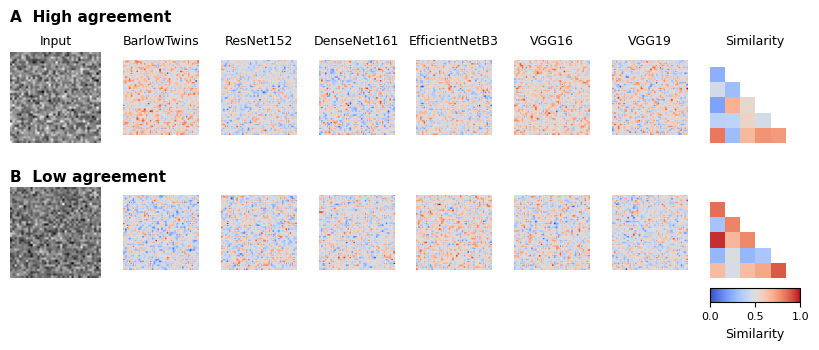

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ------------------------------
# Configuration
# ------------------------------
models = ["BarlowTwins", "ResNet152", "DenseNet161",
          "EfficientNetB3", "VGG16", "VGG19"]

model_to_file = {
    "BarlowTwins": "barlowtwins.png",
    "ResNet152": "resnet152.png",
    "DenseNet161": "densenet161.png",
    "EfficientNetB3": "efficientnetb3.png",
    "VGG16": "vgg16.png",
    "VGG19": "vgg19.png",
}

if "PROJECT_ROOT" in globals():
    images_root = PROJECT_ROOT / "main" / "Experiments" / "test" / "images"
else:
    images_root = Path("images")

high_dir = images_root / "high"
low_dir = images_root / "low"

# ------------------------------
# Figure layout (A4-ready)
# ------------------------------
fig = plt.figure(figsize=(7.6, 3.8))

# Columns: Input | 6 models
widths = [1.2] + [1] * 6

gs = GridSpec(
    2, len(widths),
    width_ratios=widths,
    height_ratios=[1, 1],
    left=0.05, right=0.98,
    top=0.82, bottom=0.16,
    wspace=0.28, hspace=0.45
)

# ------------------------------
# Panel labels (above rows)
# ------------------------------
fig.text(0.05, 0.91, "A  High agreement",
         fontsize=11, fontweight="bold", ha="left", va="center")

fig.text(0.05, 0.49, "B  Low agreement",
         fontsize=11, fontweight="bold", ha="left", va="center")

# ------------------------------
# Column headers (top row only)
# ------------------------------
x_positions = []
for c in range(len(widths)):
    bbox = gs[0, c].get_position(fig)
    x_positions.append((bbox.x0 + bbox.x1) / 2)

headers = ["Input"] + models

for x, label in zip(x_positions, headers):
    fig.text(x, 0.83, label, fontsize=9, ha="center", va="bottom")

# ------------------------------
# Load images
# ------------------------------
high_input = plt.imread(high_dir / "original.png")
low_input = plt.imread(low_dir / "original.png")

# ------------------------------
# Input images
# ------------------------------
for r, img in enumerate([high_input, low_input]):
    ax = fig.add_subplot(gs[r, 0])
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

# ------------------------------
# Model explanation images
# ------------------------------
for c, model in enumerate(models):
    high_img = plt.imread(high_dir / model_to_file[model])
    low_img = plt.imread(low_dir / model_to_file[model])

    ax_high = fig.add_subplot(gs[0, 1 + c])
    ax_high.imshow(high_img)
    ax_high.set_xticks([])
    ax_high.set_yticks([])
    ax_high.set_frame_on(False)

    ax_low = fig.add_subplot(gs[1, 1 + c])
    ax_low.imshow(low_img)
    ax_low.set_xticks([])
    ax_low.set_yticks([])
    ax_low.set_frame_on(False)

outpath = "example_explanation_agreement.pdf"

plt.savefig(
    outpath,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [10]:
outpath = "example_explanation_agreement.pdf"

plt.savefig(
    outpath,
    format="pdf",
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>